# Imports e Configuração

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

TECNICA_ATUAL = "Undersampling" 
PASTA_DADOS = os.path.join("..", "PreProcessing", TECNICA_ATUAL)

NOME_X_TRAIN = "X_train_under.csv"
NOME_Y_TRAIN = "y_train_under.csv"
NOME_X_TEST  = "X_test_scaled.csv"
NOME_Y_TEST  = "y_test.csv"

print(f"Treinamento ENSEMBLE Hard Voting (RandomForest + GradientBoosting) - Dados: {TECNICA_ATUAL}")

📕 Treinamento ENSEMBLE (Hard Voting) - Dados: Undersampling


# Carregamento

In [2]:
try:
    path_X_train = os.path.join(PASTA_DADOS, NOME_X_TRAIN)
    path_y_train = os.path.join(PASTA_DADOS, NOME_Y_TRAIN)
    path_X_test  = os.path.join(PASTA_DADOS, NOME_X_TEST)
    path_y_test  = os.path.join(PASTA_DADOS, NOME_Y_TEST)

    X_train = pd.read_csv(path_X_train)
    y_train = pd.read_csv(path_y_train).values.ravel()
    X_test = pd.read_csv(path_X_test)
    y_test = pd.read_csv(path_y_test).values.ravel()
    print("✅ Dados de Undersampling carregados com sucesso!")
except Exception as e:
    print(f"❌ Erro ao ler arquivos: {e}")

✅ Dados de Undersampling carregados com sucesso!


# Treinamento

In [3]:
clf_rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)

clf_gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)

clf_lr = LogisticRegression(max_iter=1000, random_state=42)

ensemble_hard = VotingClassifier(
    estimators=[
        ('RF', clf_rf), 
        ('GB', clf_gb), 
        ('LR', clf_lr)
    ], 
    voting='hard'
)

ensemble_hard.fit(X_train, y_train)
print("✅ Treinamento Concluído!")

✅ Treinamento Concluído!


# Avaliação

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.88      0.84      0.86       138
 Benigno (1)       0.76      0.49      0.60       142
  Câncer (2)       0.10      0.54      0.17        13

    accuracy                           0.66       293
   macro avg       0.58      0.62      0.54       293
weighted avg       0.79      0.66      0.70       293



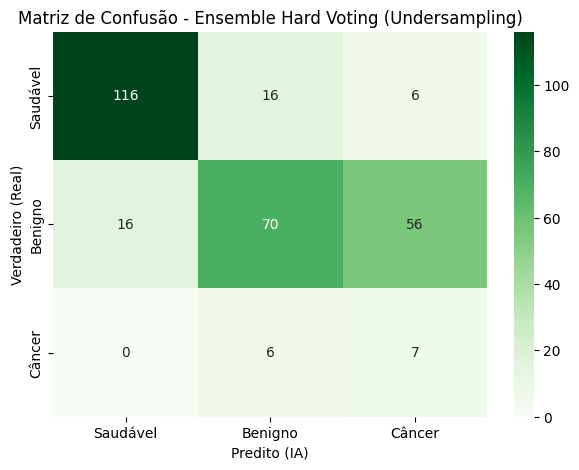

Modelo salvo!


In [4]:
y_pred = ensemble_hard.predict(X_test)

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Benigno (1)', 'Câncer (2)']))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Saudável', 'Benigno', 'Câncer'], 
            yticklabels=['Saudável', 'Benigno', 'Câncer'])
plt.title(f"Matriz de Confusão - Ensemble Hard Voting ({TECNICA_ATUAL})")
plt.ylabel("Verdadeiro (Real)")
plt.xlabel("Predito (IA)")
plt.show()

joblib.dump(ensemble_hard, os.path.join(PASTA_DADOS, 'modelo_ensemble_undersampling.pkl'))
print("Modelo salvo!")